In [31]:

import numpy as np
from numpy.typing import NDArray, ArrayLike
from typing import Union
import matplotlib.pyplot as plt
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda
from DecayFitNet.python.toolbox.DecayFitNetToolbox import DecayFitNetToolbox

from slope2noise.utils import schroeder_backward_int, db, save_audio, calculate_amplitudes_least_squares, octave_filtering

In [32]:
def decay_kernel(envelope_t: Union[float, ArrayLike],
                 time: ArrayLike,
                 fs: float,
                 normalise_envelope: bool = False,
                 add_noise: bool = True) -> NDArray:
    """
    Decay kernel for the exponential envelope
    Args:
        envelope_t: the T60 values 
        time (ArrayLike): time vector
        fs (float): sampling rate
        normalise_envelope (bool): whether to normalise the energy of the envelope to 1
        add_noise (bool): whether to add noise to the decay kernel
    Returns:
        NDArray: exp(-t/tau) exponential decay kernel, or exp(-t/tau) + n(t) with noise
    """

    tau_vals = np.log(10**6) / envelope_t
    exponential = np.exp(-np.einsum('nb,t->ntb', tau_vals, time))

    # normalise the kernel to have unit energy
    if normalise_envelope:
        exponential = np.einsum('ntb, nb -> ntb', exponential,
                                np.sqrt((1 - np.exp(-2 * tau_vals / fs))))

    # calculate noise
    ir_len = len(time)
    noise = np.linspace(1, 1 / ir_len, ir_len)

    # construct the decay kernel
    if add_noise:
        return np.concatenate((exponential, noise), axis=0)
    else:
        return exponential

Here we are testing the code used to generate impulse responses by shaping white gaussian noise.   
The envelope is adjusted to match a target EDC, following the common slope model.  
First, define the T and A energy decay parameters (in the Schroeder backward integration sense)


In [33]:
T_s = np.array([[0.5, 1.5]])  # T60 in seconds
A_s = np.array([2, 0.1])   # decay model amplitude (energy)
n_slopes = T_s.shape[-1]
fs = 48000  # sampling frequency in Hz
L = 3*fs   # length of the impulse response in samples

time_axis = np.arange(0, L) / fs

### Target Energy Decay Curve 
Construct the EDC of the desired RIR from the T_s and A_s values

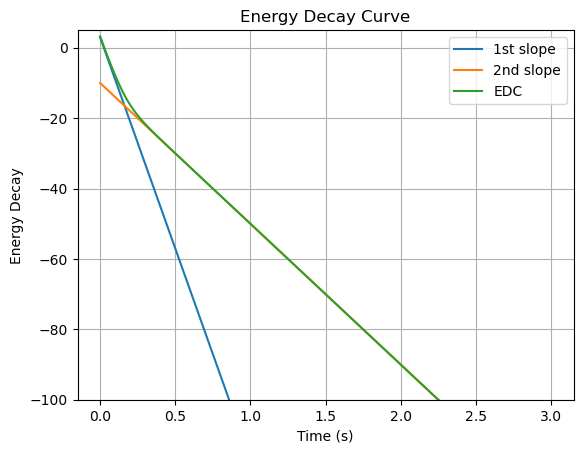

In [42]:
envelope_kernel = decay_kernel( T_s,
                                time_axis,
                                fs,
                                normalise_envelope=False,
                                add_noise=False)
edc = A_s*envelope_kernel
plt.plot(time_axis, 10*np.log10(edc[0, :, 0]), label='1st slope')
plt.plot(time_axis, 10*np.log10(edc[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), label='EDC')
plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.title('Energy Decay Curve')
plt.ylim([-100, 5])
plt.grid(True)
plt.show()

### Shaped Noise
Here the Schroeder T and A values are adapted and used to define the envelopes, which are then multiplied with the wgn


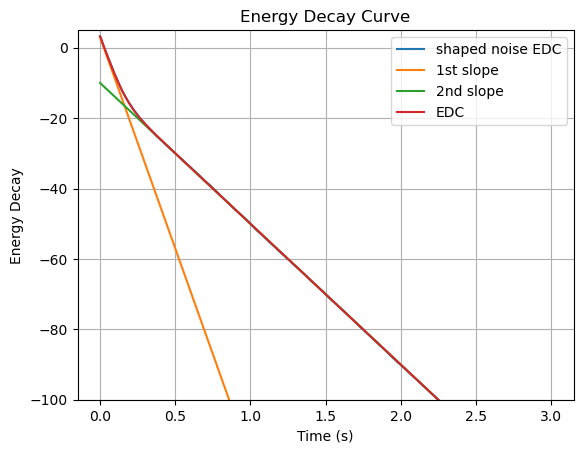

In [43]:
T_e = 2 * T_s
A_e = np.sqrt(A_s) * np.sqrt(1-np.exp(-np.log(1e6)/fs/T_s))
envelope_kernel = decay_kernel( T_e,
                                time_axis,
                                fs,
                                normalise_envelope=False,
                                add_noise=False)
gaussian_noise = np.random.randn(1, L, n_slopes)
shaped_noise = A_e*envelope_kernel*gaussian_noise
# use schroeder backward integration to get the EDC
sn_int = schroeder_backward_int(np.sum(shaped_noise, axis=-1), normalize=False)
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(edc[0, :, 0]), label='1st slope')
plt.plot(time_axis, 10*np.log10(edc[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), label='EDC')
plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.title('Energy Decay Curve')
plt.ylim([-100, 5])
plt.grid(True)
plt.show()

Let's double check with linear least squares that we are producing an RIR with correct A values.  
Let's also use BDA to confirm that the shaped noise has the target EDC. BDA estimated both T_s and A_s. 

In [36]:
A_ls = calculate_amplitudes_least_squares(
    T_s,
    fs,
    np.sum(shaped_noise, axis=-1, keepdims=True),
    f_bands=None,
    leave_out_ms=50.0,
)

BDA = bda.BayesianDecayAnalysis(n_slopes,
                                fs,
                                filter_frequencies=None, )
decayfitnet = DecayFitNetToolbox(n_slopes,
                                fs,
                                filter_frequencies=None, )
# shaped_noise = shaped_noise/np.sum(shaped_noise**2)
edc_param, norm_vals = BDA.estimate_parameters(np.sum(shaped_noise,-1))
# edc_param, norm_vals = decayfitnet.estimate_parameters(np.sum(shaped_noise,-1), analyse_full_rir=True)
# norm_vals = np.transpose(norm_vals.numpy())
norm_vals = np.transpose(norm_vals)
# BDA takes the EDC parameters estimates for each band
T, A, N = edc_param[0], edc_param[1], edc_param[2]
# amplitudes with least squares
print(
    f"Estimated T_BDA: \n {np.median(np.squeeze(np.round(T, 3)), axis=0)}, \nA_BDA: \n {np.squeeze(np.round(A, 3))} \n" \
    f"Estimated A_LS: {np.squeeze(np.round(A_ls, 3))} \n" \
    f"Reference T: {np.squeeze(np.round(T_s, 3))}, A: {np.squeeze(np.round(A_s, 3))}"
)
print(
    f"Noise level: \n {N}")
print(
    f"Normalization values: \n {norm_vals}")

Estimated T_BDA: 
 [0.856  1.5595], 
A_BDA: 
 [[0.248 0.017]
 [0.658 0.046]
 [0.215 0.009]
 [0.248 0.009]
 [0.376 0.1  ]
 [0.248 0.1  ]] 
Estimated A_LS: [1.339 0.064] 
Reference T: [0.5 1.5], A: [2.  0.1]
Noise level: 
 [[6.97934115e-14]
 [6.97934115e-14]
 [6.97934115e-14]
 [6.97934115e-14]
 [6.97934115e-14]
 [6.97934115e-14]]
Normalization values: 
 [[0.00855777]
 [0.01931735]
 [0.03004461]
 [0.07126527]
 [0.14128538]
 [0.27093422]]


Generate the EDC from the BDA estimations 

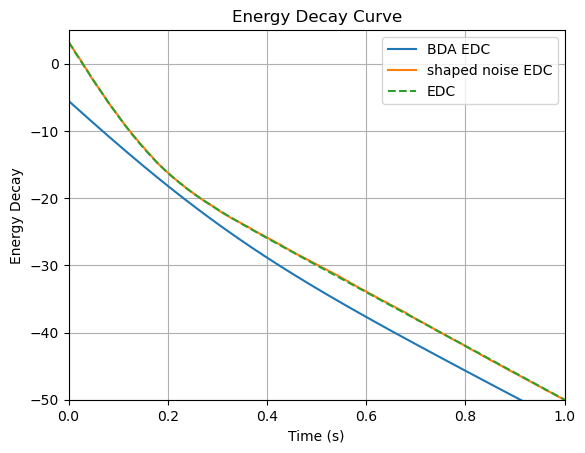

In [37]:
envelope_kernel = decay_kernel( np.median(np.squeeze(np.round(T, 3)), axis=0).reshape(1, -1),
                                time_axis,
                                fs,
                                normalise_envelope=False,
                                add_noise=False)
edc_bda = np.median(np.squeeze(np.round(A, 3)),axis=0) * envelope_kernel
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 0]), label='1st slope')
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc_bda[0, :, :], axis=-1)), label='BDA EDC')
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.ylim([-50, 5])
plt.xlim([0, 1])
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()

what if we "denormalize" the A values that BDA is estimating?  
Note that since we are working on synthetic data, the noise component is negligible 

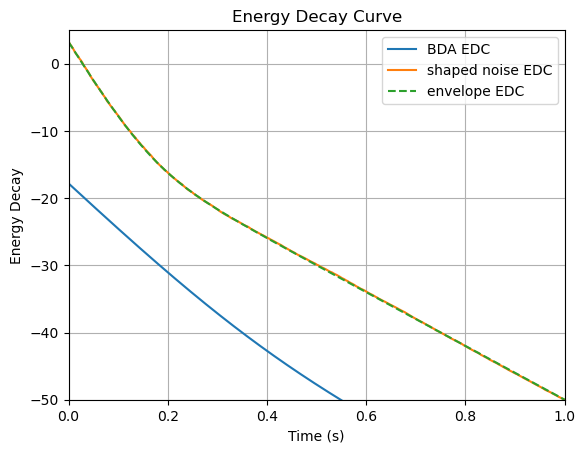

In [38]:
A_n = A*norm_vals
envelope_kernel = decay_kernel( np.median(np.squeeze(np.round(T, 3)), axis=0).reshape(1, -1),
                                time_axis,
                                fs,
                                normalise_envelope=False,
                                add_noise=False)
edc_bda = np.median(np.squeeze(np.round(A_n, 3)),axis=0) * envelope_kernel
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 0]), label='1st slope')
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc_bda[0, :, :], axis=-1)), label='BDA EDC')
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='envelope EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.ylim([-50, 5])
plt.xlim([0, 1])
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()

Maybe we need to compensate for the energy of the octave filter bank? 
The results look much better if we do so! 

In [39]:
A_n = A * norm_vals
# Estimate the energy of the octave filters
inpulse = np.zeros((L, 1))
inpulse[0] = 1
rirFBands = octave_filtering(inpulse, fs, BDA.get_filter_frequencies(), get_filter=True)
bandEnergy = np.expand_dims(sum(rirFBands**2), -1)  
# initial level
A_n =  A_n / bandEnergy
print(A_n)

[[0.98062603 0.06918123]
 [2.9397046  0.20739035]
 [0.74859524 0.0324049 ]
 [1.02081193 0.03843291]
 [1.53814835 0.4085457 ]
 [0.97072129 0.39188186]]


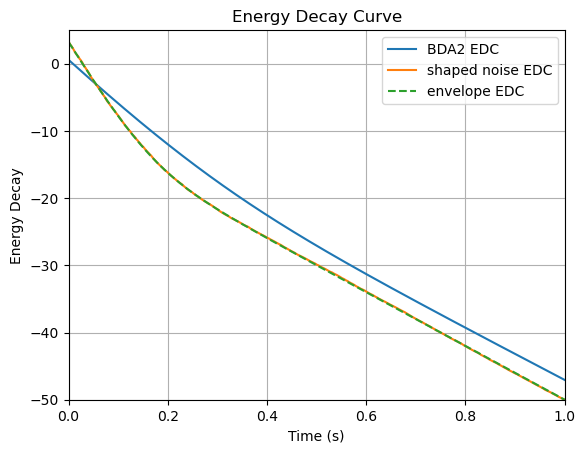

In [40]:
envelope_kernel = decay_kernel( np.median(np.squeeze(np.round(T, 3)), axis=0).reshape(1, -1),
                                time_axis,
                                fs,
                                normalise_envelope=False,
                                add_noise=False)
edc_bda = np.median(np.squeeze(np.round(A_n, 3)),axis=0) * envelope_kernel
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 0]), label='1st slope')
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc_bda[0, :, :], axis=-1)), label='BDA2 EDC')
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='envelope EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.ylim([-50, 5])
plt.xlim([0, 1])
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()